In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We do the same calculations that we did in "btc_std_calc_2_states.ipynb". Refer to that.

In [2]:
# Refer to "32_states_transitions_and_means.ipynb"
P = np.genfromtxt("mat_32_states.csv")

In [ ]:
# Refer to "32_states_transitions_and_means.ipynb"
pi = np.genfromtxt("pi_32_states.csv",delimiter=",")

In [4]:
pi

array([0.023539, 0.003631, 0.004351, 0.004908, 0.005761, 0.006716,
       0.007919, 0.009753, 0.011837, 0.014832, 0.01964 , 0.027232,
       0.040041, 0.063363, 0.087297, 0.143815, 0.167521, 0.096336,
       0.068901, 0.044054, 0.030403, 0.021985, 0.016874, 0.013032,
       0.009954, 0.008905, 0.006858, 0.005727, 0.004984, 0.004162,
       0.00359 , 0.022079])

In [5]:
Pi = np.vstack([pi]*32)

In [ ]:
# Refer to "32_states_transitions_and_means.ipynb"
a_star = 0.144272

In [8]:
a = np.linspace(start=-20,stop=20,num=33)
a = np.delete(a,16)

In [9]:
b = np.array(a-a_star)

In [10]:
b

array([-20.144272, -18.894272, -17.644272, -16.394272, -15.144272,
       -13.894272, -12.644272, -11.394272, -10.144272,  -8.894272,
        -7.644272,  -6.394272,  -5.144272,  -3.894272,  -2.644272,
        -1.394272,   1.105728,   2.355728,   3.605728,   4.855728,
         6.105728,   7.355728,   8.605728,   9.855728,  11.105728,
        12.355728,  13.605728,  14.855728,  16.105728,  17.355728,
        18.605728,  19.855728])

In [11]:
len(b)

32

$$ g:= (P + \Pi^* -I){^-1} b$$

In [12]:
A= np.linalg.inv(P + Pi - np.eye(32))

In [13]:
print(A)

[[-1.08612760e+00 -5.74371634e-03 -5.06970292e-03 ...  3.22616069e-03
   1.23941832e-03 -2.14893874e-02]
 [-4.34943040e-02 -1.00578633e+00 -5.35007658e-03 ...  8.06499934e-03
  -3.41038349e-03  2.98558958e-02]
 [-1.87474037e-02 -4.15372193e-03 -9.98210430e-01 ...  1.66494395e-03
   6.36597860e-03  3.63474495e-02]
 ...
 [ 3.50379973e-02  7.44592686e-03  4.43652852e-03 ... -1.00552734e+00
  -6.72192654e-03 -2.30866893e-02]
 [ 2.81604210e-02  9.49235225e-04  8.72477380e-03 ... -7.18396762e-03
  -1.00561493e+00 -5.00047515e-02]
 [-1.81224181e-02  4.00639625e-03  5.76151615e-03 ... -6.57769754e-03
  -7.82162127e-03 -1.09316235e+00]]


In [14]:
g = np.matmul(A,b)


In [15]:
print(g)

[ 23.6294041   22.93215118  21.19534361  20.13028015  19.07912354
  17.78548165  16.18901926  14.97076998  13.62544505  11.94544311
  10.48142348   8.76142679   7.05624258   5.17170967   3.71992316
   2.80456788  -2.26731453  -3.05513704  -4.72705269  -6.39299054
  -8.2964147  -10.01897209 -11.6010245  -13.44767659 -14.836347
 -16.26929888 -17.59633425 -19.27745544 -20.39290771 -21.81873002
 -23.45360897 -24.00430556]


$$\implies g = [-23.64838916 -18.07983908 -13.38403188  -6.87852121   5.27719905
  12.01255187  17.12603744  22.30218313]$$

In [16]:
v = np.zeros(len(g))

In [17]:
for i in range(len(v)):
    s = 0
    for j in range(len(v)):
        s += ((g[j]-g[i])**2)* P[i,j]
    s_2=0
    for j in range(len(v)):
        s_2 += (g[j]-g[i])*P[i,j]
    v[i] = b[i]**2 + s - 2*(b[i])*s_2

In [18]:
print(v)

[199.42693082 152.91930984 134.78638341 138.46078294 137.16326728
 127.45094599 131.02794406 128.02044336 117.40988989 111.65692383
 102.49839424  94.07211711  85.16298217  70.66618078  59.70118397
  50.82297198  51.20108357  58.00652141  70.73905504  79.22414723
  93.71127881  94.16531943 106.61225063 115.15431283 117.11982293
 123.8601007  126.3105448  137.44915288 145.90518949 134.92425774
 152.53517403 196.61542827]


$$\sigma ^2 = \sum \pi _i v(i) $$

In [19]:
sigma = np.sqrt(np.matmul(pi,v))

In [20]:
print(sigma)

8.90647155871277


But we see that we need $$\sigma \sqrt{(\frac{\lambda }{1-\hat{h}})}$$

We have $$\lambda = 0.00031458686590702084, a =  0.02230285826488395, b =  0.04458713874443153$$

In [21]:
lamb = 0.16508945342301887

a=0.011477956127453995

b = 0.20470834799305934

We have $$h(t,z) = z a \exp(-bt)$$

$$H(z):= \int _0 ^ \infty h(t,z) dt$$ 

Thus in our case we have $$H(z) = \frac{az}{b}$$

Now we take the density of Z as $f(z)$

An observation before gave us $$f(z) = \frac{1}{\sqrt{2 \pi \sigma ^2}} \exp({-1/2 \frac{(z-\mu)^2}{\sigma ^2} })$$

When we fitted , got $$\mu = 13.329567797401769,$$

In [22]:
mu = 13.329567797401769


$$\hat{h} := \int{H(z)f(z)} dz$$

In [23]:
h_hat = a/b * mu

In [24]:
print(h_hat)

0.7473862003013596


In [25]:
par =  (sigma * np.sqrt(lamb/(1-h_hat)))

In [26]:
print(par)

7.2000715888858275


In [27]:
data_interval =  np.linspace(0, +1200, 100)

In [28]:
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]


Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


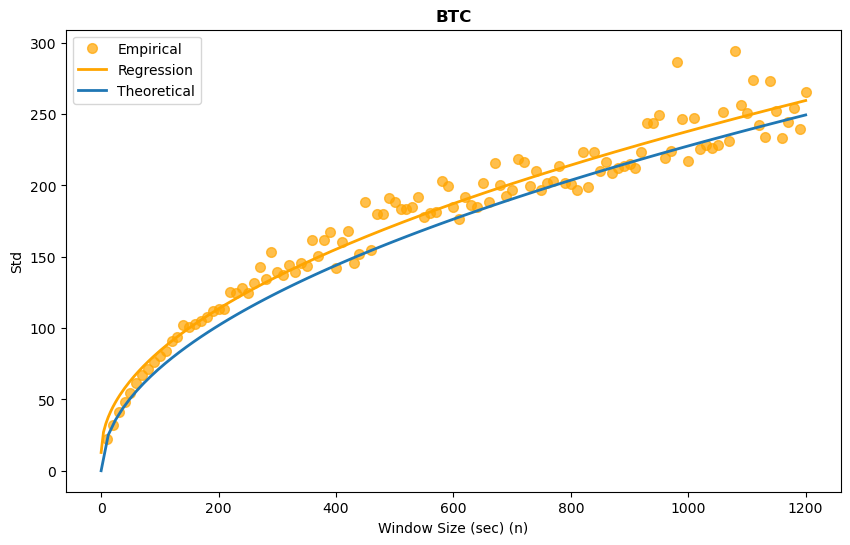

In [29]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="orange",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)

plt.plot(data_interval,np.sqrt(data_interval)*par,label = "Theoretical",linewidth = 2 )




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

In [30]:
y_hat = np.sqrt(x)*par

In [31]:
MSE = np.array([(y[i]-y_hat[i])**2   for i in range(len(y_hat))])

In [32]:
MSE = np.sum(MSE) / len(MSE)

In [35]:
print(f"Mean square error: {MSE}")

Mean square error: 278.2838591780509


In [36]:
print(f"Percentage error:%{((par-7.123004)/7.123004)*100}")

Percentage error:%1.0819534691518866
